Implementing a journal titled : **A hybrid explainable ensemble transformer encoder for pneumonia identification**
from chest X-ray images

Authors: Chiagoziem C. Ukwuoma, Zhiguang Qin, Md Belal Bin Heyat, Faijan Akhtar, Olusola Bamisile, Abdullah Y. Muaad, Daniel Addo, Mugahed A. Al-antari

Year: 2023

In [ ]:
# --- Kaggle API Setup ---
# since our dataset size is too long, hence we are directly using an api key to call the dataset from Kaggle

!pip install -q kaggle # Installing the Kaggle library

from google.colab import files # Importing the 'files' module for file uploads

print("Please upload your kaggle.json API key...")
files.upload()

!mkdir -p ~/.kaggle # Creating the .kaggle directory if it doesn't exist
!mv kaggle.json ~/.kaggle/ # Move the uploaded kaggle.json file to the .kaggle directory
!chmod 600 ~/.kaggle/kaggle.json # Setting the file permissions for kaggle.json

print("Kaggle API configured successfully!")

Please upload your kaggle.json API key...


Saving kaggle.json to kaggle.json
Kaggle API configured successfully!


# 1. Import the required libraries

In [ ]:
# importing the required dependencies
from tensorflow.keras.preprocessing import image_dataset_from_directory # Import the utility to load image datasets from directories
from tensorflow.keras import backend as K # Importing Keras backend for custom metrics
import os, sys, random, math, json, pathlib
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

print("Python:", sys.version)
print("TensorFlow:", tf.__version__)

# Checking and printing available GPUs
print("GPU Available:", tf.config.list_physical_devices('GPU'))

Python: 3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]
TensorFlow: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# 2. Data Acquisition

For the problem identified by you, students have to find the data source themselves from any data source.

Provide the URL of the data used.

Write Code for converting the above downloaded data into a form suitable for DL


In [ ]:
# --- Download dataset from Kaggle ---

# since our dataset size is too long, hence we are directly using an api key to call the dataset from Kaggle

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content/
# Unzip the downloaded dataset into the /content/ directory quietly (-q)
!unzip -q /content/chest-xray-pneumonia.zip -d /content/

# Set dataset path
DATA_DIR = "/content/chest_xray" # Defining the path to the extracted dataset
print("Dataset ready at:", DATA_DIR)
!ls -R $DATA_DIR | head -20 # List the contents of the dataset directory recursively

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
 99% 2.27G/2.29G [00:31<00:00, 52.8MB/s]
100% 2.29G/2.29G [00:31<00:00, 77.0MB/s]
Dataset ready at: /content/chest_xray
/content/chest_xray:
chest_xray
__MACOSX
test
train
val

/content/chest_xray/chest_xray:
test
train
val

/content/chest_xray/chest_xray/test:
NORMAL
PNEUMONIA

/content/chest_xray/chest_xray/test/NORMAL:
IM-0001-0001.jpeg
IM-0003-0001.jpeg
IM-0005-0001.jpeg


# 3. Data Preparation

Perform the data prepracessing that is required for the data that you have downloaded.


This stage depends on the dataset that is used.

In [ ]:
IMG_SIZE = (224, 224) # Defining the target image size
BATCH_SIZE = 24 # Defining the batch size for training
SEED = 42 # Setting a random seed for reproducibility
EPOCHS = 15 # Defining the number of training epochs
LEARNING_RATE = 2e-4 # Defining the learning rate for the optimizer

# Backbones for ensemble
BACKBONES = ['DenseNet201', 'InceptionResNetV2', 'VGG16'] # listing the pre-trained CNN backbones

# Transformer Encoder settings
D_MODEL = 512 # Dimensionality of the transformer encoder model
NUM_HEADS = 4 # Number of attention heads in the multi-head attention mechanism
FF_DIM = 512 # Dimensionality of the feed-forward network in the transformer encoder
ENCODER_LAYERS = 2 # Number of transformer encoder layers
DROPOUT_RATE = 0.2 # Dropout rate for regularization

In [ ]:
train_dir = os.path.join(DATA_DIR, 'train') # Defining the path to the training data
val_dir   = os.path.join(DATA_DIR, 'val') # Defining the path to the validation data
test_dir  = os.path.join(DATA_DIR, 'test') # Defining the path to the test data

# Creating the training dataset from directory
train_ds = image_dataset_from_directory(train_dir, label_mode='binary',
                                       image_size=IMG_SIZE, batch_size=BATCH_SIZE,
                                       seed=SEED, shuffle=True)

# Creating the validation dataset from directory
val_ds = image_dataset_from_directory(val_dir, label_mode='binary',
                                     image_size=IMG_SIZE, batch_size=BATCH_SIZE,
                                     seed=SEED, shuffle=False)

# Creating the test dataset from directory
test_ds = image_dataset_from_directory(test_dir, label_mode='binary',
                                      image_size=IMG_SIZE, batch_size=BATCH_SIZE,
                                      seed=SEED, shuffle=False)

class_names = train_ds.class_names # Getting the class names from the training dataset
print("Classes:", class_names)

# Configuring the dataset
AUTOTUNE = tf.data.AUTOTUNE

# prefetching the datasets for performance
train_ds = train_ds.prefetch(AUTOTUNE) # Prefetch training data
val_ds = val_ds.prefetch(AUTOTUNE) # Prefetch validation data
test_ds = test_ds.prefetch(AUTOTUNE) # Prefetch test data

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Classes: ['NORMAL', 'PNEUMONIA']


In [ ]:
# Defining the data augmentation layers
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"), # Randomly flip images horizontally
    layers.RandomRotation(0.02), # Randomly rotate images by a small factor
    layers.RandomZoom(0.1), # Randomly zoom into images
], name="augmentation")

# Defining rescaling layer to normalize pixel values
rescale = layers.Rescaling(1./255)

# 4. Deep Neural Network Architecture
  
 ## 4.1 Design the architecture that you will be using

CNN / RNN / Transformer as per the journal referenced

In [ ]:
# Function to build a pre-trained CNN backbone
def build_backbone(name, input_tensor):
    name = name.lower() # lowercasing operation to handle case sensitivity
    if name == "densenet201":
        from tensorflow.keras.applications import DenseNet201 # Importing DenseNet201
        from tensorflow.keras.applications.densenet import preprocess_input
        x = layers.Lambda(preprocess_input)(input_tensor)
        base = DenseNet201(include_top=False, weights="imagenet", input_tensor=x) # Loading DenseNet201 without the top classification layer
        return layers.GlobalAveragePooling2D()(base.output) # Applying Global Average Pooling to the output features
    if name == "vgg16":
        from tensorflow.keras.applications import VGG16 # Importing VGG16
        from tensorflow.keras.applications.vgg16 import preprocess_input
        x = layers.Lambda(preprocess_input)(input_tensor)
        base = VGG16(include_top=False, weights="imagenet", input_tensor=x) # Loading VGG16 without the top classification layer
        return layers.GlobalAveragePooling2D()(base.output) # Applying Global Average Pooling
    if name == "inceptionresnetv2":
        from tensorflow.keras.applications import InceptionResNetV2 # Importing InceptionResNetV2
        from tensorflow.keras.applications.inception_resnet_v2 import preprocess_input
        x = layers.Lambda(preprocess_input)(input_tensor)
        base = InceptionResNetV2(include_top=False, weights="imagenet", input_tensor=x) # Loading InceptionResNetV2 without the top classification layer
        return layers.GlobalAveragePooling2D()(base.output) # Applying Global Average Pooling
    raise ValueError(f"Unknown backbone: {name}") # Raise an error if the backbone name is unknown

In [ ]:
# Function to build a Transformer Encoder layer
def transformer_encoder(x, num_heads=4, key_dim=128, ff_dim=256, dropout=0.2):
    # Multi-Head Self-Attention
    attn_out = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x)
    # Adding skip connection and layer normalization
    x = layers.Add()([x, attn_out])
    x = layers.LayerNormalization()(x)


    # Feed-Forward Network
    ff = layers.Dense(ff_dim, activation="gelu")(x) # Dense layer with GELU activation
    ff = layers.Dropout(dropout)(ff)
    ff = layers.Dense(x.shape[-1])(ff)
    # Adding skip connection and layer normalization
    x = layers.Add()([x, ff])
    x = layers.LayerNormalization()(x)
    return x

## 4.2 DNN Report

Report the following and provide justification for the same.

* Number of layers
* Number of units in each layer
* Total number of trainable parameters



In [ ]:
# Defining the input layer for the model
inp = keras.Input(shape=IMG_SIZE + (3,), name="input_image")
# Applying data augmentation to the input image
x_aug = data_augmentation(inp)
# Rescaling pixel values to the range [0, 1]
x = rescale(x_aug)

tokens = [] # Initializing a list to store feature tokens from backbones
# Iterating through each defined backbone
for bname in BACKBONES:
    feat = build_backbone(bname, x) # Build the backbone and get features
    tok = layers.Dense(D_MODEL)(feat) # Project features to the desired model dimension
    tokens.append(tok) # Adding the projected features as a token

# Stack the tokens to create a sequence of tokens
seq = layers.Lambda(lambda tt: tf.stack(tt, axis=1))(tokens)

# Adding positional embeddings to the sequence of tokens
positions = tf.range(start=0, limit=seq.shape[1], delta=1) # Creating a tensor of positions
pos_emb = layers.Embedding(input_dim=seq.shape[1], output_dim=D_MODEL)(positions) # Creating positional embeddings
seq = seq + pos_emb # Addding positional embeddings to the token sequence

# Applying Transformer Encoder layers
for _ in range(ENCODER_LAYERS):
    seq = transformer_encoder(seq, num_heads=NUM_HEADS,
                              key_dim=D_MODEL//NUM_HEADS, # Key dimension is d_model / num_heads
                              ff_dim=FF_DIM, dropout=DROPOUT_RATE) # Applying transformer encoder layer

# Applying Global Average Pooling to the sequence of tokens
seq_pooled = layers.GlobalAveragePooling1D()(seq)
# Applying dropout for regularization
h = layers.Dropout(0.3)(seq_pooled)
# Adding a dense layer with ReLU activation
h = layers.Dense(256, activation="relu")(h)
# Applying dropout again
h = layers.Dropout(0.3)(h)
# Output dense layer with sigmoid activation for binary classification
out = layers.Dense(1, activation="sigmoid")(h)

# Creating the hybrid ensemble transformer model
model = keras.Model(inp, out, name="HybridEnsembleTransformer")
# Printing a summary of the model architecture
model.summary()

74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "HybridEnsembleTransformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ augmentation[0][… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ lambda[0][0]      │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],    

 Total params: 92,694,113 (353.60 MB)

 Trainable params: 92,404,513 (352.50 MB)

 Non-trainable params: 289,600 (1.10 MB)

# 5. Training the model

In [ ]:
# Defining custom precision metric
def precision_m(y_true, y_pred):
    y_pred_bin = K.cast(K.greater_equal(y_pred, 0.5), "float32") # Convert predictions to binary (0 or 1) based on a threshold of 0.5
    tp = K.sum(y_true * y_pred_bin) # Calculating  True Positives
    fp = K.sum((1 - y_true) * y_pred_bin) # Calculating  False Positives
    return tp / (tp + fp + K.epsilon()) # Calculating  precision

# Defining the custom recall metric
def recall_m(y_true, y_pred):
    y_pred_bin = K.cast(K.greater_equal(y_pred, 0.5), "float32") # Convert predictions to binary
    tp = K.sum(y_true * y_pred_bin) # Calculating  True Positives
    fn = K.sum(y_true * (1 - y_pred_bin)) # Calculating  False Negatives
    return tp / (tp + fn + K.epsilon()) # Calculating  recall (avoid division by zero)

# Defining custom F1-score metric
def f1_m(y_true, y_pred):
    p = precision_m(y_true, y_pred) # Calculating  precision
    r = recall_m(y_true, y_pred) # Calculating  recall
    return 2 * ((p * r) / (p + r + K.epsilon())) # Calculating  F1-score (harmonic mean of precision and recall)

opt = keras.optimizers.Adam(learning_rate=LEARNING_RATE) # Defining the Adam optimizer with the specified learning rate
# Compile the model
model.compile(optimizer=opt, loss="binary_crossentropy", # Use binary crossentropy as the loss function for binary classification
              metrics=["accuracy", keras.metrics.AUC(name="auc"), precision_m, recall_m, f1_m]) # Defining the metrics to monitor during training

# 6. Test the model

In [ ]:
# Defining callbacks for training
callbacks = [
    # Model Checkpoint to save the best model based on validation F1-score
    keras.callbacks.ModelCheckpoint("best_model.keras", monitor="val_f1_m", mode="max",
                                    save_best_only=True, verbose=1),
    # Early Stopping to stop training when validation F1-score stops improving
    keras.callbacks.EarlyStopping(monitor="val_f1_m", mode="max", patience=5, # Stopping the model if no improvement for 5 epochs
                                  restore_best_weights=True, verbose=1) # Restore the model weights from the best epoch
]

# Training the model
history = model.fit(train_ds, validation_data=val_ds,
                    epochs=EPOCHS, callbacks=callbacks)

Epoch 1/15
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9072 - auc: 0.9458 - f1_m: 0.9376 - loss: 0.2343 - precision_m: 0.9391 - recall_m: 0.9439
Epoch 1: val_f1_m improved from -inf to 0.66667, saving model to best_model.keras
218/218 ━━━━━━━━━━━━━━━━━━━━ 701s 2s/step - accuracy: 0.9074 - auc: 0.9460 - f1_m: 0.9377 - loss: 0.2340 - precision_m: 0.9392 - recall_m: 0.9439 - val_accuracy: 0.5000 - val_auc: 0.8125 - val_f1_m: 0.6667 - val_loss: 2.2810 - val_precision_m: 0.5000 - val_recall_m: 1.0000
Epoch 2/15
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9629 - auc: 0.9927 - f1_m: 0.9741 - loss: 0.0952 - precision_m: 0.9772 - recall_m: 0.9731
Epoch 2: val_f1_m did not improve from 0.66667
218/218 ━━━━━━━━━━━━━━━━━━━━ 382s 2s/step - accuracy: 0.9629 - auc: 0.9927 - f1_m: 0.9741 - loss: 0.0952 - precision_m: 0.9772 - recall_m: 0.9731 - val_accuracy: 0.5000 - val_auc: 0.5625 - val_f1_m: 0.6667 - val_loss: 3.2373 - val_precision_m: 0.5000 - val_recall_m: 1.0000
Epoch 3/15
21

# 7. Report the result

1. Plot the training and validation accuracy history.
2. Plot the training and validation loss history.
3. Report the testing accuracy and loss.
4. Show Confusion Matrix for testing dataset.
5. Report values for preformance study metrics like accuracy, precision, recall, F1 Score.

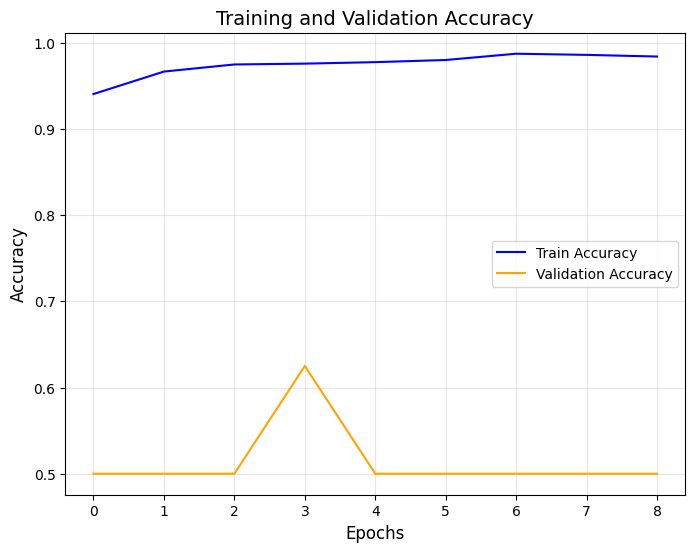

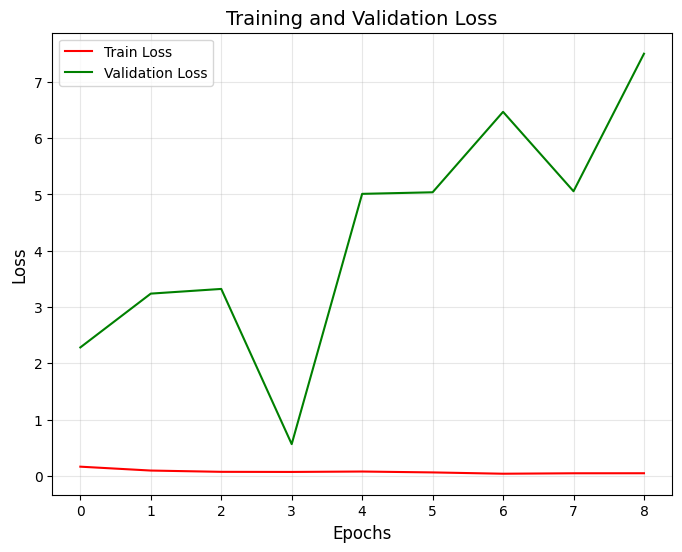


Test Accuracy: 0.7099
Test Loss: 0.9171


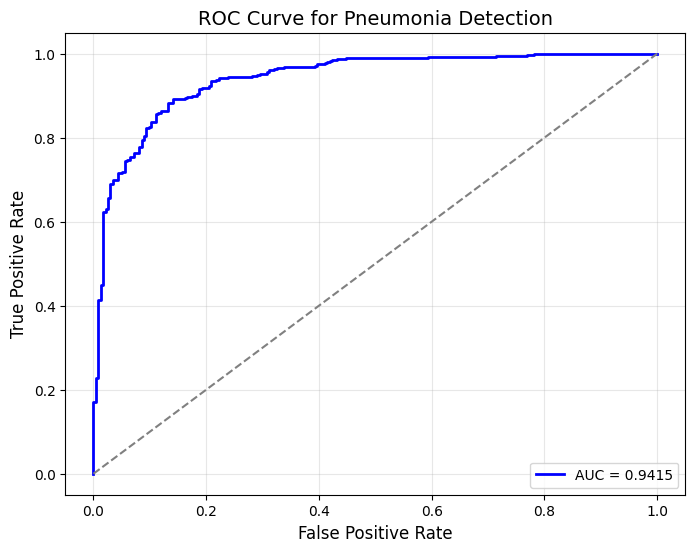

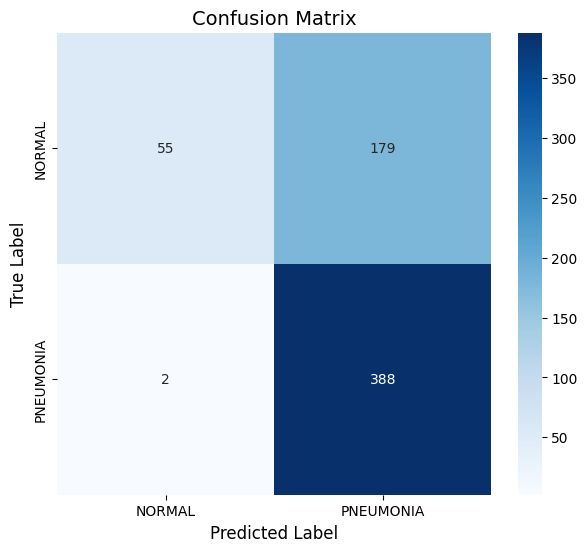


Classification Report:

              precision    recall  f1-score   support

      NORMAL       0.96      0.24      0.38       234
   PNEUMONIA       0.68      0.99      0.81       390

    accuracy                           0.71       624
   macro avg       0.82      0.61      0.59       624
weighted avg       0.79      0.71      0.65       624



In [ ]:
# Plotting required graphs

# 1. Plotting Training & Validation Accuracy
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 2. Plotting Training & Validation Loss
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='green')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 3. Reporting the Test Accuracy & Loss
test_results = model.evaluate(test_ds, verbose=0)
test_loss = test_results[0]
test_acc = test_results[1] # Accuracy is the second metric in the compiled list
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Collecting the Predictions
y_true = []
y_prob = []
for batch, labels in test_ds:
    y_true.append(labels.numpy().ravel())
    y_prob.append(model.predict(batch, verbose=0).ravel())

y_true = np.concatenate(y_true)
y_prob = np.concatenate(y_prob)
y_pred = (y_prob >= 0.5).astype(int)

# Plotting ROC Curve
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_true, y_prob)
auc = roc_auc_score(y_true, y_prob)
plt.plot(fpr, tpr, color="blue", linewidth=2, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curve for Pneumonia Detection", fontsize=14)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# 4. Displaying the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.show()

# 5. Printing the Classification Report (Precision, Recall, F1, Accuracy)
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

## Summary and Conclusion

Based on the test set evaluation:

*   **Test Accuracy:** 0.7099
*   **Test Loss:** 0.9171

**Key Points:**

*   Strong performance on identifying Pneumonia cases (high recall, 0.99), but lower performance on Normal cases (low recall, 0.24).

**Conclusion:**

The model effectively detects Pneumonia but struggles with Normal cases